# Week9 Graph Construction

第九周任务：

1. 读取 PVODdatasets_v1.0 多站点光伏数据；
2. 对齐多站点时间序列；
3. 构造距离图 $A_{dist}$；
4. 构造相关性图 $A_{corr}$；
5. 可视化邻接矩阵，并解释空间上的邻居关系。

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'week9' else _cwd
sys.path.insert(0, os.path.join(_root, 'week9'))

from data import load_aligned_pvod_data
from graph_utils import (
    build_distance_matrix,
    build_distance_adjacency,
    build_correlation_matrix,
    build_correlation_adjacency,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.unicode_minus'] = False

## 1. 读取并对齐多站点数据

这里把 10 个光伏站点按公共时间区间对齐，方便后续构图与建模。

In [2]:
aligned = load_aligned_pvod_data()

print(f'Station count: {len(aligned.station_ids)}')
print(f'Feature tensor shape: {aligned.feature_tensor.shape}')
print(f'Power matrix shape: {aligned.power_frame.shape}')
print(f'Time range: {aligned.timestamps.min()} -> {aligned.timestamps.max()}')
aligned.metadata[['Station_ID', 'Capacity', 'Longitude', 'Latitude']]

Station count: 10
Feature tensor shape: (8160, 10, 6)
Power matrix shape: (8160, 10)
Time range: 2019-03-04 16:00:00 -> 2019-06-10 15:45:00


,Station_ID,Capacity,Longitude,Latitude
0,station00,6600.0,114.951390,38.047780
1,station01,20000.0,117.457220,38.183060
2,station02,17000.0,114.198870,38.057280
3,station03,20000.0,114.114940,38.109560
4,station04,20000.0,114.867670,39.515500
5,station05,35000.0,114.123600,38.235500
6,station06,15000.0,114.548410,36.898910
7,station07,20000.0,113.641870,36.644030
8,station08,20000.0,113.899990,36.707610
9,station09,20000.0,115.059855,38.731417


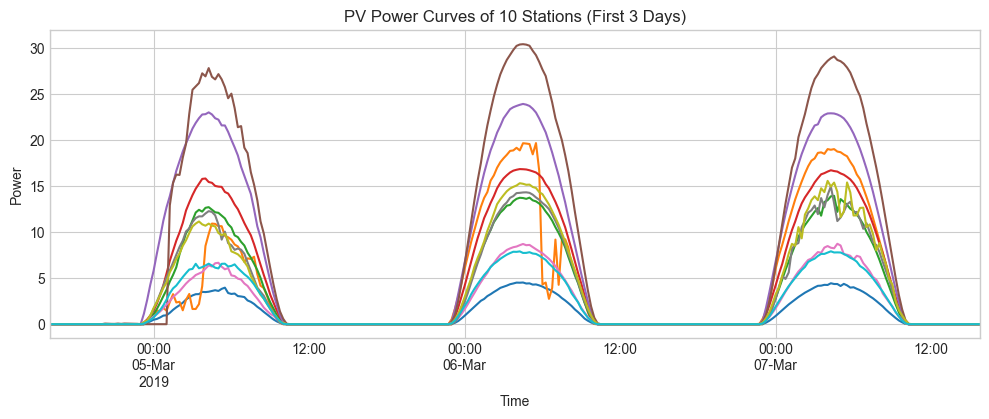

In [3]:
# 先看各站点功率曲线的前 3 天，帮助理解数据形态。
view_steps = 3 * 24 * 4
aligned.power_frame.iloc[:view_steps].plot(figsize=(12, 4), legend=False)
plt.title('PV Power Curves of 10 Stations (First 3 Days)')
plt.xlabel('Time')
plt.ylabel('Power')
plt.show()

## 2. 距离图 $A_{dist}$

根据站点经纬度计算球面距离，再按阈值构造邻接矩阵。

In [4]:
DIST_THRESHOLD_KM = 150.0

distance_df = build_distance_matrix(aligned.metadata)
adj_dist = build_distance_adjacency(aligned.metadata, threshold_km=DIST_THRESHOLD_KM)

print('Distance matrix:')
display(distance_df.round(2).style.format("{:.2f}"))
print('Distance adjacency:')
display(adj_dist)

Distance matrix:


,station00,station01,station02,station03,station04,station05,station06,station07,station08,station09
station00,0.00,219.73,65.90,73.53,163.36,75.34,132.61,194.33,175.60,76.60
station01,219.73,0.00,285.37,292.37,268.76,291.31,293.51,377.89,354.27,217.46
station02,65.90,285.37,0.00,9.37,172.20,20.88,132.45,164.68,152.38,106.06
station03,73.53,292.37,9.37,0.00,169.39,14.02,139.94,168.23,157.04,107.51
station04,163.36,268.76,172.20,169.39,0.00,156.22,292.29,336.83,323.49,88.75
station05,75.34,291.31,20.88,14.02,156.22,0.00,153.27,182.00,171.04,98.40
station06,132.61,293.51,132.45,139.94,292.29,153.27,0.00,85.57,61.53,208.66
station07,194.33,377.89,164.68,168.23,336.83,182.00,85.57,0.00,24.08,263.51
station08,175.60,354.27,152.38,157.04,323.49,171.04,61.53,24.08,0.00,247.08
station09,76.60,217.46,106.06,107.51,88.75,98.40,208.66,263.51,247.08,0.00


Distance adjacency:


,station00,station01,station02,station03,station04,station05,station06,station07,station08,station09
station00,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
station01,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
station02,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
station03,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
station04,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
station05,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
station06,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
station07,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
station08,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
station09,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0


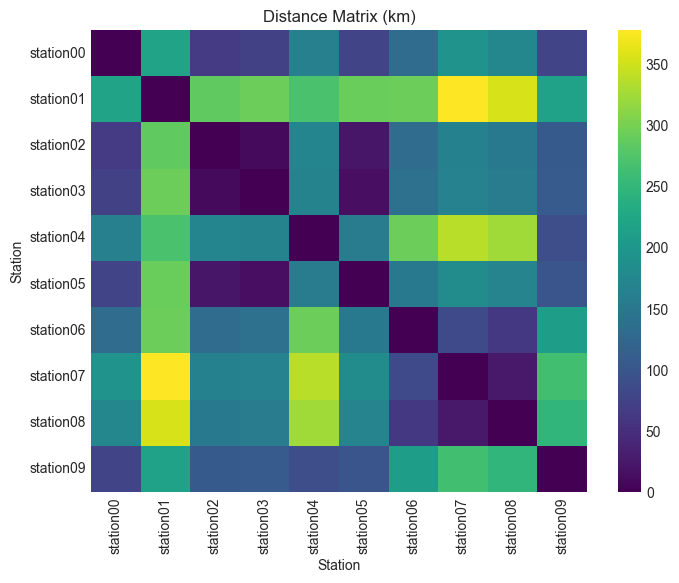

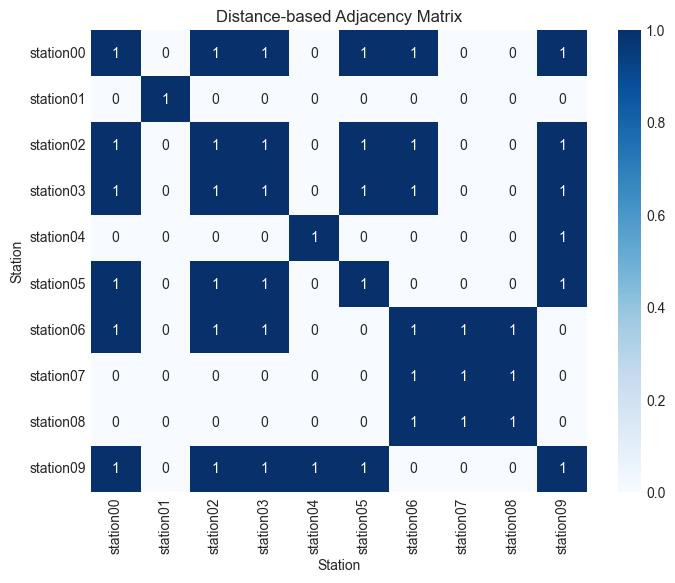

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(distance_df, cmap='viridis', annot=False)
plt.title('Distance Matrix (km)')
plt.xlabel('Station')
plt.ylabel('Station')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(adj_dist, cmap='Blues', annot=True, fmt='.0f')
plt.title('Distance-based Adjacency Matrix')
plt.xlabel('Station')
plt.ylabel('Station')
plt.show()

## 3. 相关性图 $A_{corr}$

根据多站点功率序列计算 Pearson 相关系数，并按阈值构造相关性图。

In [6]:
CORR_THRESHOLD = 0.90

corr_df = build_correlation_matrix(aligned.power_frame)
adj_corr = build_correlation_adjacency(aligned.power_frame, threshold=CORR_THRESHOLD)

print('Correlation matrix:')
display(corr_df.round(3))
print('Correlation adjacency:')
display(adj_corr)

Correlation matrix:


,station00,station01,station02,station03,station04,station05,station06,station07,station08,station09
station00,1.000,0.915,0.929,0.932,0.902,0.925,0.922,0.907,0.906,0.915
station01,0.915,1.000,0.913,0.917,0.891,0.910,0.908,0.901,0.903,0.900
station02,0.929,0.913,1.000,0.977,0.919,0.959,0.931,0.934,0.937,0.928
station03,0.932,0.917,0.977,1.000,0.922,0.960,0.920,0.933,0.939,0.925
station04,0.902,0.891,0.919,0.922,1.000,0.923,0.883,0.883,0.890,0.899
station05,0.925,0.910,0.959,0.960,0.923,1.000,0.919,0.926,0.926,0.937
station06,0.922,0.908,0.931,0.920,0.883,0.919,1.000,0.928,0.936,0.916
station07,0.907,0.901,0.934,0.933,0.883,0.926,0.928,1.000,0.957,0.897
station08,0.906,0.903,0.937,0.939,0.890,0.926,0.936,0.957,1.000,0.903
station09,0.915,0.900,0.928,0.925,0.899,0.937,0.916,0.897,0.903,1.000


Correlation adjacency:


,station00,station01,station02,station03,station04,station05,station06,station07,station08,station09
station00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
station01,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
station02,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
station03,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
station04,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
station05,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
station06,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
station07,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
station08,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
station09,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0


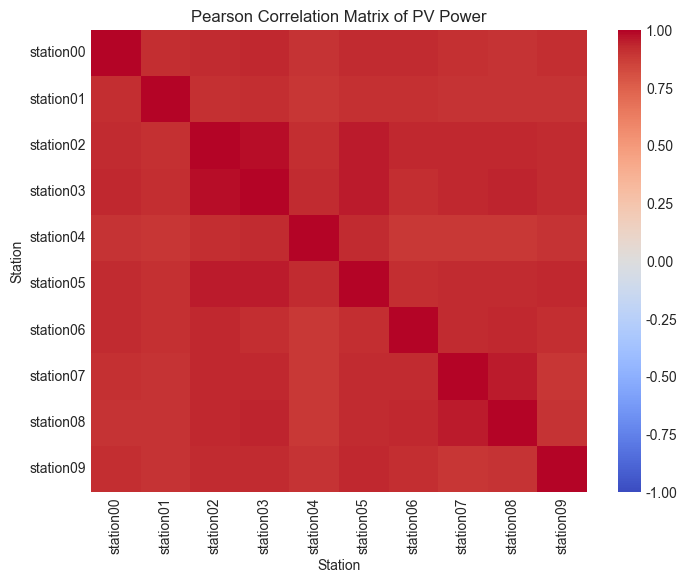

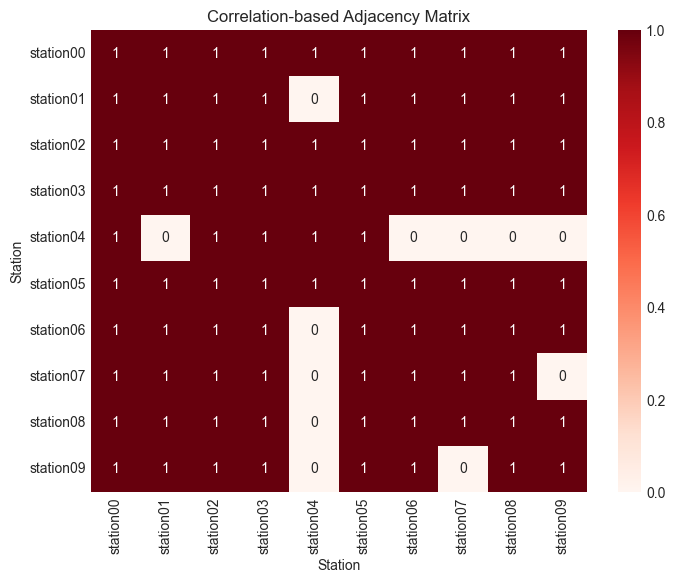

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title('Pearson Correlation Matrix of PV Power')
plt.xlabel('Station')
plt.ylabel('Station')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(adj_corr, cmap='Reds', annot=True, fmt='.0f')
plt.title('Correlation-based Adjacency Matrix')
plt.xlabel('Station')
plt.ylabel('Station')
plt.show()

## 4. 第九周检查点说明

本周重点不是训练模型，而是解释站点之间的空间关系：

1. 在 `A_dist` 中，值为 1 的站点对表示它们在空间上距离较近，可视为邻居；
2. 在 `A_corr` 中，值为 1 的站点对表示它们的功率变化趋势高度一致；
3. 两种图可以分别用于“物理邻近关系”和“统计相似关系”的建模。

## 5. 站点经纬度相对位置地图

下面使用 GeoPandas + Cartopy 将各个光伏站点画到地图坐标系中。点表示站点位置，点大小表示装机容量，灰色连线表示距离邻接矩阵 A_dist 中判定为相邻的站点对。

In [ ]:
import geopandas as gpd
import cartopy.crs as ccrs

# 从第九周数据对象中提取站点元数据，并构造成 GeoDataFrame。
station_geo = aligned.metadata[['Station_ID', 'Capacity', 'Longitude', 'Latitude']].copy()
station_geo['Longitude'] = station_geo['Longitude'].astype(float)
station_geo['Latitude'] = station_geo['Latitude'].astype(float)
station_geo['Capacity'] = station_geo['Capacity'].astype(float)

station_gdf = gpd.GeoDataFrame(
    station_geo,
    geometry=gpd.points_from_xy(station_geo['Longitude'], station_geo['Latitude']),
    crs='EPSG:4326',
)

# 根据站点经纬度自动设置地图范围，避免地图过大导致站点挤在一起。
lon_min, lon_max = station_gdf['Longitude'].min(), station_gdf['Longitude'].max()
lat_min, lat_max = station_gdf['Latitude'].min(), station_gdf['Latitude'].max()
lon_margin = max((lon_max - lon_min) * 0.25, 0.05)
lat_margin = max((lat_max - lat_min) * 0.25, 0.05)

fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(
    [lon_min - lon_margin, lon_max + lon_margin, lat_min - lat_margin, lat_max + lat_margin],
    crs=ccrs.PlateCarree(),
)

# Use Cartopy built-in stock image as background to avoid online Natural Earth downloads.
try:
    ax.stock_img()
except Exception as exc:
    ax.set_facecolor('#eef6fb')
    print(f'Cartopy stock image skipped: {exc}')

gridlines = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5, linestyle='--')
gridlines.top_labels = False
gridlines.right_labels = False

# 将距离邻接矩阵中的边画成灰色连线，帮助观察物理邻近关系。
if 'adj_dist' in globals():
    coord_by_station = station_gdf.set_index('Station_ID')[['Longitude', 'Latitude']]
    for i, src in enumerate(aligned.station_ids):
        for j, dst in enumerate(aligned.station_ids):
            if j <= i or float(adj_dist.loc[src, dst]) <= 0:
                continue
            lon_pair = [coord_by_station.loc[src, 'Longitude'], coord_by_station.loc[dst, 'Longitude']]
            lat_pair = [coord_by_station.loc[src, 'Latitude'], coord_by_station.loc[dst, 'Latitude']]
            ax.plot(lon_pair, lat_pair, color='#707070', linewidth=1.0, alpha=0.55, transform=ccrs.PlateCarree(), zorder=2)

# 点大小表示装机容量；如果容量完全相同，则使用统一大小。
capacity = station_gdf['Capacity']
if capacity.max() > capacity.min():
    point_size = 80 + 220 * (capacity - capacity.min()) / (capacity.max() - capacity.min())
else:
    point_size = np.full(len(station_gdf), 140.0)

scatter = ax.scatter(
    station_gdf['Longitude'],
    station_gdf['Latitude'],
    s=point_size,
    c=capacity,
    cmap='YlOrRd',
    edgecolor='black',
    linewidth=0.8,
    alpha=0.95,
    transform=ccrs.PlateCarree(),
    zorder=3,
)

for _, row in station_gdf.iterrows():
    label = str(row['Station_ID']).replace('station', 'S')
    ax.text(
        row['Longitude'] + lon_margin * 0.03,
        row['Latitude'] + lat_margin * 0.03,
        label,
        fontsize=8,
        weight='bold',
        transform=ccrs.PlateCarree(),
        zorder=4,
    )

cbar = plt.colorbar(scatter, ax=ax, shrink=0.72, pad=0.04)
cbar.set_label('Capacity')
ax.set_title('Relative Geographic Positions of PV Stations')
plt.show()

display(station_gdf[['Station_ID', 'Capacity', 'Longitude', 'Latitude']])
